In [4]:
import pandas as pd

# 加载四个数据集
train = pd.read_parquet("train_clean.parquet")
val = pd.read_parquet("validation_clean.parquet")
test = pd.read_parquet("test_clean.parquet")
recent = pd.read_parquet("recent_clean.parquet")

# 看形状：多少行、多少列
print("train shape:", train.shape)
print("val shape:", val.shape)
print("test shape:", test.shape)
print("recent shape:", recent.shape)

# 看所有列名
print("\n所有列名：")
for i, col in enumerate(train.columns):
    print(f"{i}: {col}")

train shape: (216023, 120)
val shape: (43875, 120)
test shape: (46039, 120)
recent shape: (42204, 120)

所有列名：
0: cik
1: ticker
2: company_name
3: adsh
4: sic
5: fiscal_year
6: fiscal_quarter
7: filing_date
8: period_end_date
9: total_assets
10: current_assets
11: cash_and_equivalents
12: short_term_investments
13: accounts_receivable
14: inventory
15: property_plant_equipment
16: goodwill
17: intangible_assets
18: total_liabilities
19: current_liabilities
20: accounts_payable
21: long_term_debt
22: total_debt
23: stockholders_equity
24: retained_earnings
25: revenue
26: cost_of_revenue
27: gross_profit
28: operating_income
29: net_income
30: eps_basic
31: eps_diluted
32: interest_expense
33: income_tax_expense
34: depreciation_amortization
35: research_development
36: sga_expense
37: operating_cash_flow
38: capex
39: dividends_paid
40: shares_outstanding
41: free_cash_flow
42: book_value_per_share
43: gross_margin
44: operating_margin
45: net_margin
46: roe
47: roa
48: debt_to_equity
4

In [5]:
# 先看所有包含 target 的列名
target_cols = [c for c in train.columns if c.startswith("target_")]
print("目标列：")
for c in target_cols:
    print(c)

目标列：
target_bvps_growth_1y
target_equity_growth_1y
target_earnings_growth_1y
target_revenue_growth_1y
target_ocf_growth_1y
target_fcf_growth_1y
target_roe_fwd_1y
target_margin_expansion_1y
target_roa_improved_1y
target_fundamentals_improved_1y
target_value_created_1y
target_survived_1y
target_bankrupt_1y
target_bvps_growth_2y
target_equity_growth_2y
target_earnings_growth_2y
target_revenue_growth_2y
target_ocf_growth_2y
target_fcf_growth_2y
target_survived_2y
target_bankrupt_2y
target_bvps_growth_1y_rank
target_equity_growth_1y_rank
target_earnings_growth_1y_rank
target_revenue_growth_1y_rank
target_ocf_growth_1y_rank
target_fcf_growth_1y_rank
target_roe_fwd_1y_rank
target_margin_expansion_1y_rank
target_bvps_growth_2y_rank
target_equity_growth_2y_rank
target_earnings_growth_2y_rank
target_revenue_growth_2y_rank
target_ocf_growth_2y_rank
target_fcf_growth_2y_rank


In [7]:
target = "target_bankrupt_1y"

# 看分布
print("train 中 target_bankrupt_1y 的分布：")
print(train[target].value_counts(dropna=False))

print("\n正样本（破产）比例：")
print(train[target].mean())

train 中 target_bankrupt_1y 的分布：
False    214645
True       1378
Name: target_bankrupt_1y, dtype: int64

正样本（破产）比例：
0.006378950389541854


In [8]:
all_cols = train.columns.tolist()

# 目标列：所有 target_ 开头的列
target_cols = [c for c in all_cols if c.startswith("target_")]

# 标识符列：不能作为特征的列
id_cols = [c for c in all_cols if c.lower() in 
           ["cik", "period", "fiscal_year", "fiscal_quarter", 
            "company_name", "ticker", "sic", "form", "filed", "date"]]

# QA标志列：名字里带 qa 或 flag 的
qa_cols = [c for c in all_cols if "qa" in c.lower() or "flag" in c.lower()]

# 候选特征列 = 全部 - 目标 - 标识符
feature_cols = [c for c in all_cols if c not in target_cols + id_cols]

print(f"总列数: {len(all_cols)}")
print(f"目标列数: {len(target_cols)}")
print(f"标识符列: {id_cols}")
print(f"QA标志列: {qa_cols}")
print(f"候选特征列数: {len(feature_cols)}")
print("\n候选特征列：")
for c in feature_cols:
    print(c)

总列数: 120
目标列数: 35
标识符列: ['cik', 'ticker', 'company_name', 'sic', 'fiscal_year', 'fiscal_quarter']
QA标志列: ['qa_impossible_value', 'qa_temporal_anomaly', 'qa_pass']
候选特征列数: 79

候选特征列：
adsh
filing_date
period_end_date
total_assets
current_assets
cash_and_equivalents
short_term_investments
accounts_receivable
inventory
property_plant_equipment
goodwill
intangible_assets
total_liabilities
current_liabilities
accounts_payable
long_term_debt
total_debt
stockholders_equity
retained_earnings
revenue
cost_of_revenue
gross_profit
operating_income
net_income
eps_basic
eps_diluted
interest_expense
income_tax_expense
depreciation_amortization
research_development
sga_expense
operating_cash_flow
capex
dividends_paid
shares_outstanding
free_cash_flow
book_value_per_share
gross_margin
operating_margin
net_margin
roe
roa
debt_to_equity
current_ratio
f_roa
f_cfo
f_delta_roa
f_accrual
f_delta_lever
f_delta_liquid
f_equity
f_delta_margin
f_delta_turn
f_score
z_prime_score
z_prime_zone
is_distressed
beneish

In [9]:
# 1. 直接泄露答案的列
leak_cols = ["is_bankrupt", "bankruptcy_date", "bankruptcy_chapter", "label_timestamp"]

# 2. 标识符/元数据，不能做特征
meta_cols = ["adsh", "filing_date", "period_end_date", 
             "source_file", "parse_timestamp", "enrichment_timestamp", "split"]

# 3. QA标志，用来过滤数据行，不是特征
qa_cols = ["qa_impossible_value", "qa_temporal_anomaly", "qa_pass"]

# 4. 可能含未来信息的列（先删，后面讨论）
# is_distressed 可能是用当期数据算的，但和破产高度相关，先删
suspect_cols = ["is_distressed"]

# 从 feature_cols 里剔除
drop_from_features = leak_cols + meta_cols + qa_cols + suspect_cols
feature_cols_final = [c for c in feature_cols if c not in drop_from_features]

print(f"原始候选特征: {len(feature_cols)}")
print(f"删除后特征: {len(feature_cols_final)}")
print("\n删除的列：")
for c in drop_from_features:
    if c in feature_cols:
        print(f"  - {c}")

原始候选特征: 79
删除后特征: 64

删除的列：
  - is_bankrupt
  - bankruptcy_date
  - bankruptcy_chapter
  - label_timestamp
  - adsh
  - filing_date
  - period_end_date
  - source_file
  - parse_timestamp
  - enrichment_timestamp
  - split
  - qa_impossible_value
  - qa_temporal_anomaly
  - qa_pass
  - is_distressed


In [10]:
# 看看这几列的值分布
for col in ["z_prime_zone", "is_financial", "sic"]:
    if col in train.columns:
        print(f"\n{col} 的值分布：")
        print(train[col].value_counts(dropna=False).head(10))


z_prime_zone 的值分布：
NaN         135847
distress     45067
grey         24474
safe         10635
Name: z_prime_zone, dtype: int64

is_financial 的值分布：
False    162002
True      54021
Name: is_financial, dtype: int64

sic 的值分布：
2834.0    12413
6798.0    10446
6022.0     8488
1311.0     6990
7372.0     6345
7389.0     5240
6021.0     4683
6770.0     4217
3841.0     3882
3674.0     3772
Name: sic, dtype: int64


In [11]:
# 只对最终特征列看缺失率
missing = train[feature_cols_final].isnull().mean().sort_values(ascending=False)

print("缺失率最高的20个特征：")
print(missing.head(20))

print(f"\n缺失率 > 50% 的特征数: {(missing > 0.5).sum()}")
print(f"缺失率 5%-50% 的特征数: {((missing > 0.05) & (missing <= 0.5)).sum()}")
print(f"缺失率 < 5% 的特征数: {(missing <= 0.05).sum()}")

缺失率最高的20个特征：
f_score                    0.924809
short_term_investments     0.854367
dividends_paid             0.844706
free_cash_flow_margin      0.775941
f_delta_lever              0.767039
composite_quality_score    0.757827
free_cash_flow             0.755799
research_development       0.751702
f_delta_margin             0.747055
debt_to_equity             0.705235
long_term_debt             0.690380
total_debt                 0.690380
gross_margin               0.665489
capex                      0.656902
accrual_ratio              0.653671
gross_profit               0.649172
cash_conversion_ratio      0.648857
operating_cash_flow        0.646626
graham_number              0.634581
z_prime_zone               0.628854
dtype: float64

缺失率 > 50% 的特征数: 26
缺失率 5%-50% 的特征数: 28
缺失率 < 5% 的特征数: 10


In [12]:
# 从feature_cols_final里再删掉两个分类变量
feature_cols_final = [c for c in feature_cols_final if c not in ["z_prime_zone", "sic"]]

print(f"最终特征数: {len(feature_cols_final)}")
print(feature_cols_final)

最终特征数: 63
['total_assets', 'current_assets', 'cash_and_equivalents', 'short_term_investments', 'accounts_receivable', 'inventory', 'property_plant_equipment', 'goodwill', 'intangible_assets', 'total_liabilities', 'current_liabilities', 'accounts_payable', 'long_term_debt', 'total_debt', 'stockholders_equity', 'retained_earnings', 'revenue', 'cost_of_revenue', 'gross_profit', 'operating_income', 'net_income', 'eps_basic', 'eps_diluted', 'interest_expense', 'income_tax_expense', 'depreciation_amortization', 'research_development', 'sga_expense', 'operating_cash_flow', 'capex', 'dividends_paid', 'shares_outstanding', 'free_cash_flow', 'book_value_per_share', 'gross_margin', 'operating_margin', 'net_margin', 'roe', 'roa', 'debt_to_equity', 'current_ratio', 'f_roa', 'f_cfo', 'f_delta_roa', 'f_accrual', 'f_delta_lever', 'f_delta_liquid', 'f_equity', 'f_delta_margin', 'f_delta_turn', 'f_score', 'z_prime_score', 'beneish_coverage', 'graham_number', 'ncav_per_share', 'tangible_book_value_per_sh

In [13]:
# 最终特征集：删掉缺失率>80%的 + 分类变量 + 重复衍生指标
drop_high_missing = [
    "f_score", "short_term_investments", "dividends_paid",
    "f_delta_lever", "f_delta_margin", "composite_quality_score",
    "research_development", "graham_number",
    "z_prime_zone", "sic"
]

feature_cols_final = [c for c in feature_cols_final if c not in drop_high_missing]

print(f"最终特征数: {len(feature_cols_final)}")
for c in feature_cols_final:
    print(c)

最终特征数: 55
total_assets
current_assets
cash_and_equivalents
accounts_receivable
inventory
property_plant_equipment
goodwill
intangible_assets
total_liabilities
current_liabilities
accounts_payable
long_term_debt
total_debt
stockholders_equity
retained_earnings
revenue
cost_of_revenue
gross_profit
operating_income
net_income
eps_basic
eps_diluted
interest_expense
income_tax_expense
depreciation_amortization
sga_expense
operating_cash_flow
capex
shares_outstanding
free_cash_flow
book_value_per_share
gross_margin
operating_margin
net_margin
roe
roa
debt_to_equity
current_ratio
f_roa
f_cfo
f_delta_roa
f_accrual
f_delta_liquid
f_equity
f_delta_turn
z_prime_score
beneish_coverage
ncav_per_share
tangible_book_value_per_share
net_working_capital_per_share
graham_defensive_score
cash_conversion_ratio
accrual_ratio
free_cash_flow_margin
is_financial


In [20]:
print("y_train dtype:", y_train.dtype)
print("y_val dtype:", y_val.dtype)
print("y_test dtype:", y_test.dtype)

print("\ny_val 的取值情况：")
print(y_val.value_counts(dropna=False))

print("\ny_val 里 NaN 的数量：", y_val.isna().sum())
print("y_val 里非空样本数：", y_val.notna().sum())

y_train dtype: bool
y_val dtype: object
y_test dtype: object

y_val 的取值情况：
False    43711
True       163
NaN          1
Name: target_bankrupt_1y, dtype: int64

y_val 里 NaN 的数量： 1
y_val 里非空样本数： 43874


In [21]:
import numpy as np

target = "target_bankrupt_1y"

# ========== 1. 重新从原始数据取，确保干净 ==========
X_train = train[feature_cols_final].copy()
X_val   = val[feature_cols_final].copy()
X_test  = test[feature_cols_final].copy()

y_train = train[target].astype(float)
y_val   = val[target].astype(float)
y_test  = test[target].astype(float)

# ========== 2. 去掉标签为 NaN 的行 ==========
train_mask = y_train.notna()
val_mask   = y_val.notna()
test_mask  = y_test.notna()

X_train = X_train[train_mask.values].reset_index(drop=True)
y_train = y_train[train_mask].reset_index(drop=True)

X_val = X_val[val_mask.values].reset_index(drop=True)
y_val = y_val[val_mask].reset_index(drop=True)

X_test = X_test[test_mask.values].reset_index(drop=True)
y_test = y_test[test_mask].reset_index(drop=True)

# ========== 3. 特征全部转 float ==========
X_train = X_train.astype(float)
X_val   = X_val.astype(float)
X_test  = X_test.astype(float)

# ========== 4. 确认 ==========
print("y_train dtype:", y_train.dtype, "| 正样本比例:", y_train.mean())
print("y_val   dtype:", y_val.dtype,   "| 正样本比例:", y_val.mean())
print("y_test  dtype:", y_test.dtype,  "| 正样本比例:", y_test.mean())
print("\nX_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("\nX 是否还有非数值列：", X_train.select_dtypes(exclude=[np.number]).columns.tolist())

y_train dtype: float64 | 正样本比例: 0.006378950389541854
y_val   dtype: float64 | 正样本比例: 0.0037151843916670467
y_test  dtype: float64 | 正样本比例: 0.009082217973231358

X_train: (216023, 55)
X_val:   (43874, 55)
X_test:  (46024, 55)

X 是否还有非数值列： []


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# 填充
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_val_imp   = imputer.transform(X_val)

# 标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled   = scaler.transform(X_val_imp)

# 训练
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# 评估
y_val_prob = lr.predict_proba(X_val_scaled)[:, 1]

print("=== 逻辑回归 Baseline ===")
print(f"验证集 ROC-AUC: {roc_auc_score(y_val, y_val_prob):.4f}")
print(f"验证集 PR-AUC:  {average_precision_score(y_val, y_val_prob):.4f}")
print(f"验证集正样本比例: {y_val.mean():.4f}")

=== 逻辑回归 Baseline ===
验证集 ROC-AUC: 0.8556
验证集 PR-AUC:  0.0329
验证集正样本比例: 0.0037


In [23]:
#下一步：XGBoost
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score

# 注意：直接用未填充的 X_train / X_val（XGBoost 原生处理 NaN）
# 计算 scale_pos_weight 处理类别不平衡
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# 训练 XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",          # 用 PR-AUC 做评估
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 评估
y_val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

print("\n=== XGBoost ===")
print(f"验证集 ROC-AUC: {roc_auc_score(y_val, y_val_prob_xgb):.4f}")
print(f"验证集 PR-AUC:  {average_precision_score(y_val, y_val_prob_xgb):.4f}")

print("\n=== 对比 ===")
print(f"逻辑回归 PR-AUC: 0.0329")
print(f"XGBoost  PR-AUC: {average_precision_score(y_val, y_val_prob_xgb):.4f}")

scale_pos_weight: 155.77

=== XGBoost ===
验证集 ROC-AUC: 0.9223
验证集 PR-AUC:  0.1537

=== 对比 ===
逻辑回归 PR-AUC: 0.0329
XGBoost  PR-AUC: 0.1537


In [24]:
#下一步：先做 test 集评估，再做 SHAP
#第一步：在 test 集上验证泛化
# test 集评估
y_test_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("=== test 集最终评估 ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_prob_xgb):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_test_prob_xgb):.4f}")
print(f"test 正样本比例: {y_test.mean():.4f}")
print(f"随机基线 PR-AUC: {y_test.mean():.4f}")

=== test 集最终评估 ===
ROC-AUC: 0.8818
PR-AUC:  0.0940
test 正样本比例: 0.0091
随机基线 PR-AUC: 0.0091


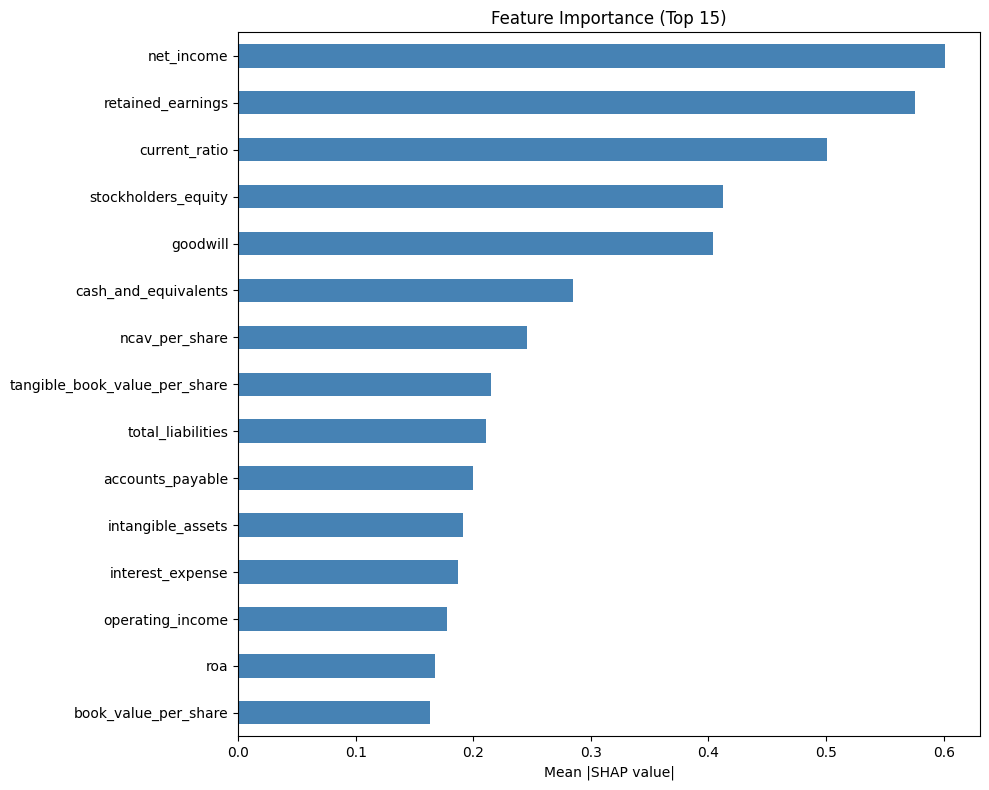

Top 15 特征重要性：
 1. net_income                               0.6009
 2. retained_earnings                        0.5753
 3. current_ratio                            0.5005
 4. stockholders_equity                      0.4125
 5. goodwill                                 0.4042
 6. cash_and_equivalents                     0.2847
 7. ncav_per_share                           0.2459
 8. tangible_book_value_per_share            0.2152
 9. total_liabilities                        0.2108
10. accounts_payable                         0.1998
11. intangible_assets                        0.1915
12. interest_expense                         0.1870
13. operating_income                         0.1776
14. roa                                      0.1673
15. book_value_per_share                     0.1632


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

explainer = shap.TreeExplainer(xgb_model)
X_val_sample = X_val.sample(n=2000, random_state=42)
sv = explainer.shap_values(X_val_sample)

# 兼容新旧版本
if hasattr(sv, "values"):
    sv = sv.values

# 计算重要性
importance = pd.Series(
    np.abs(sv).mean(axis=0),
    index=X_val_sample.columns
).sort_values(ascending=False)

top15 = importance.head(15)

plt.figure(figsize=(10, 8))
top15[::-1].plot(kind="barh", color="steelblue")
plt.xlabel("Mean |SHAP value|")
plt.title("Feature Importance (Top 15)")
plt.tight_layout()
plt.show()

print("Top 15 特征重要性：")
for i, (feat, val) in enumerate(top15.items(), 1):
    print(f"{i:2d}. {feat:40s} {val:.4f}")